# COMP 5318 Assignment 2: Image Classification

### Group number: 153
SID1: 540430668
SID2: 540776016
SID3: 520197321
SID4: ... 

This template notebook includes code to load the  dataset and a skeleton for the main sections that should be included in the notebook. Please stick to this struture for your submitted notebook.

Please focus on making your code clear, with appropriate variable names and whitespace. Include comments and markdown text to aid the readability of your code where relevant. See the specification and marking criteria in the associated specification to guide you when completing your implementation.

## Setup and dependencies
Please use this section to list and set up all your required libraries/dependencies and your plotting environment. 

In [1]:
# Install core dependencies for the notebook
!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [keras-tuner]


In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import time
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler

import keras_tuner as kt

USE_CUML = False
try:
    from cuml.linear_model import LogisticRegression
    USE_CUML = True
    print("GPU enabled for LogisticRegression using CuML")
except ImportError:
    from sklearn.linear_model import LogisticRegression
    print("GPU not available, using CPU for LogisticRegression")

HAS_CUPY = False
try:
    import cupy as cp
    HAS_CUPY = cp.cuda.is_available()
except ImportError:
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "cupy-cuda12x"],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
        import cupy as cp
        HAS_CUPY = cp.cuda.is_available()
    except Exception:
        pass
print(f"CuPy GPU acceleration: {'enabled' if HAS_CUPY else 'not available'}")

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 5318

processed_dir = Path('processed')
output_dir = Path('output')
processed_dir.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)

GPU not available, using CPU for LogisticRegression
CuPy GPU acceleration: not available


## 1. Data loading, exploration, and preprocessing


Code to load the dataset is provided in the following cell. Please proceed with your data exploration and preprocessing in the remainder of this section.

In [3]:
# Load the dataset training and test sets as numpy arrays
# assuming Assignment2Data folder is present in the same directory 
# as the notebook
X_train = np.load('Assignment2Data/X_train.npy')
y_train = np.load('Assignment2Data/y_train.npy')
X_test = np.load('Assignment2Data/X_test.npy')
y_test = np.load('Assignment2Data/y_test.npy')

### Dataset overview
Start by checking dataset size, datatype, and label coverage before plotting.

In [4]:
print(f'X_train shape: {X_train.shape}, dtype: {X_train.dtype}')
print(f'y_train shape: {y_train.shape}, dtype: {y_train.dtype}')
print(f'X_test shape: {X_test.shape}, dtype: {X_test.dtype}')
print(f'y_test shape: {y_test.shape}, dtype: {y_test.dtype}')
print(f'Pixel range in training data: [{X_train.min()}, {X_train.max()}]')
print(f'Unique class labels: {np.unique(y_train)}') 

X_train shape: (32000, 28, 28, 3), dtype: uint8
y_train shape: (32000,), dtype: uint8
X_test shape: (8000, 28, 28, 3), dtype: uint8
y_test shape: (8000,), dtype: uint8
Pixel range in training data: [0, 255]
Unique class labels: [0 1 2 3 4 5 6 7 8]


### Class distribution
This bar chart checks whether the classes are balanced in the training split.

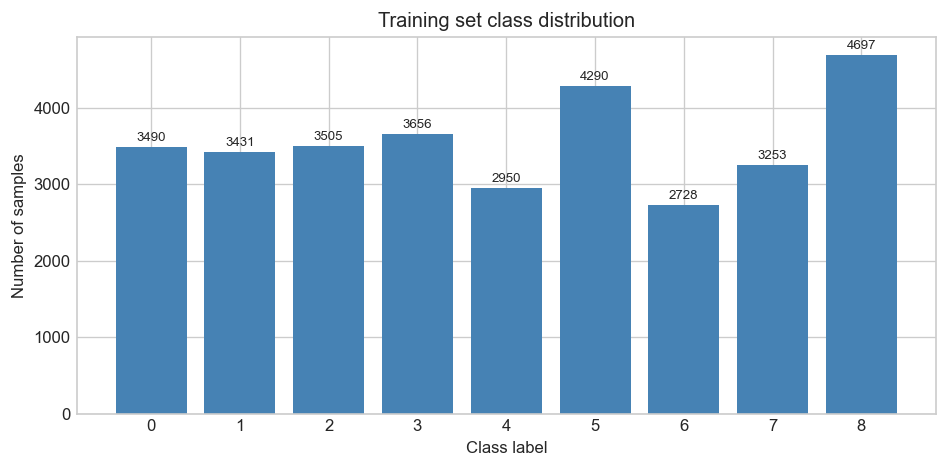

In [5]:
class_ids, class_counts = np.unique(y_train, return_counts=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(class_ids.astype(str), class_counts, color='steelblue')
ax.set_title('Training set class distribution')
ax.set_xlabel('Class label')
ax.set_ylabel('Number of samples')
for idx, count in enumerate(class_counts):
    ax.text(idx, count + 40, str(count), ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(output_dir / 'class_distribution.png', bbox_inches='tight')
plt.show()

### Sample images from each class
Display a few examples per class to inspect intra-class variation and class similarity.

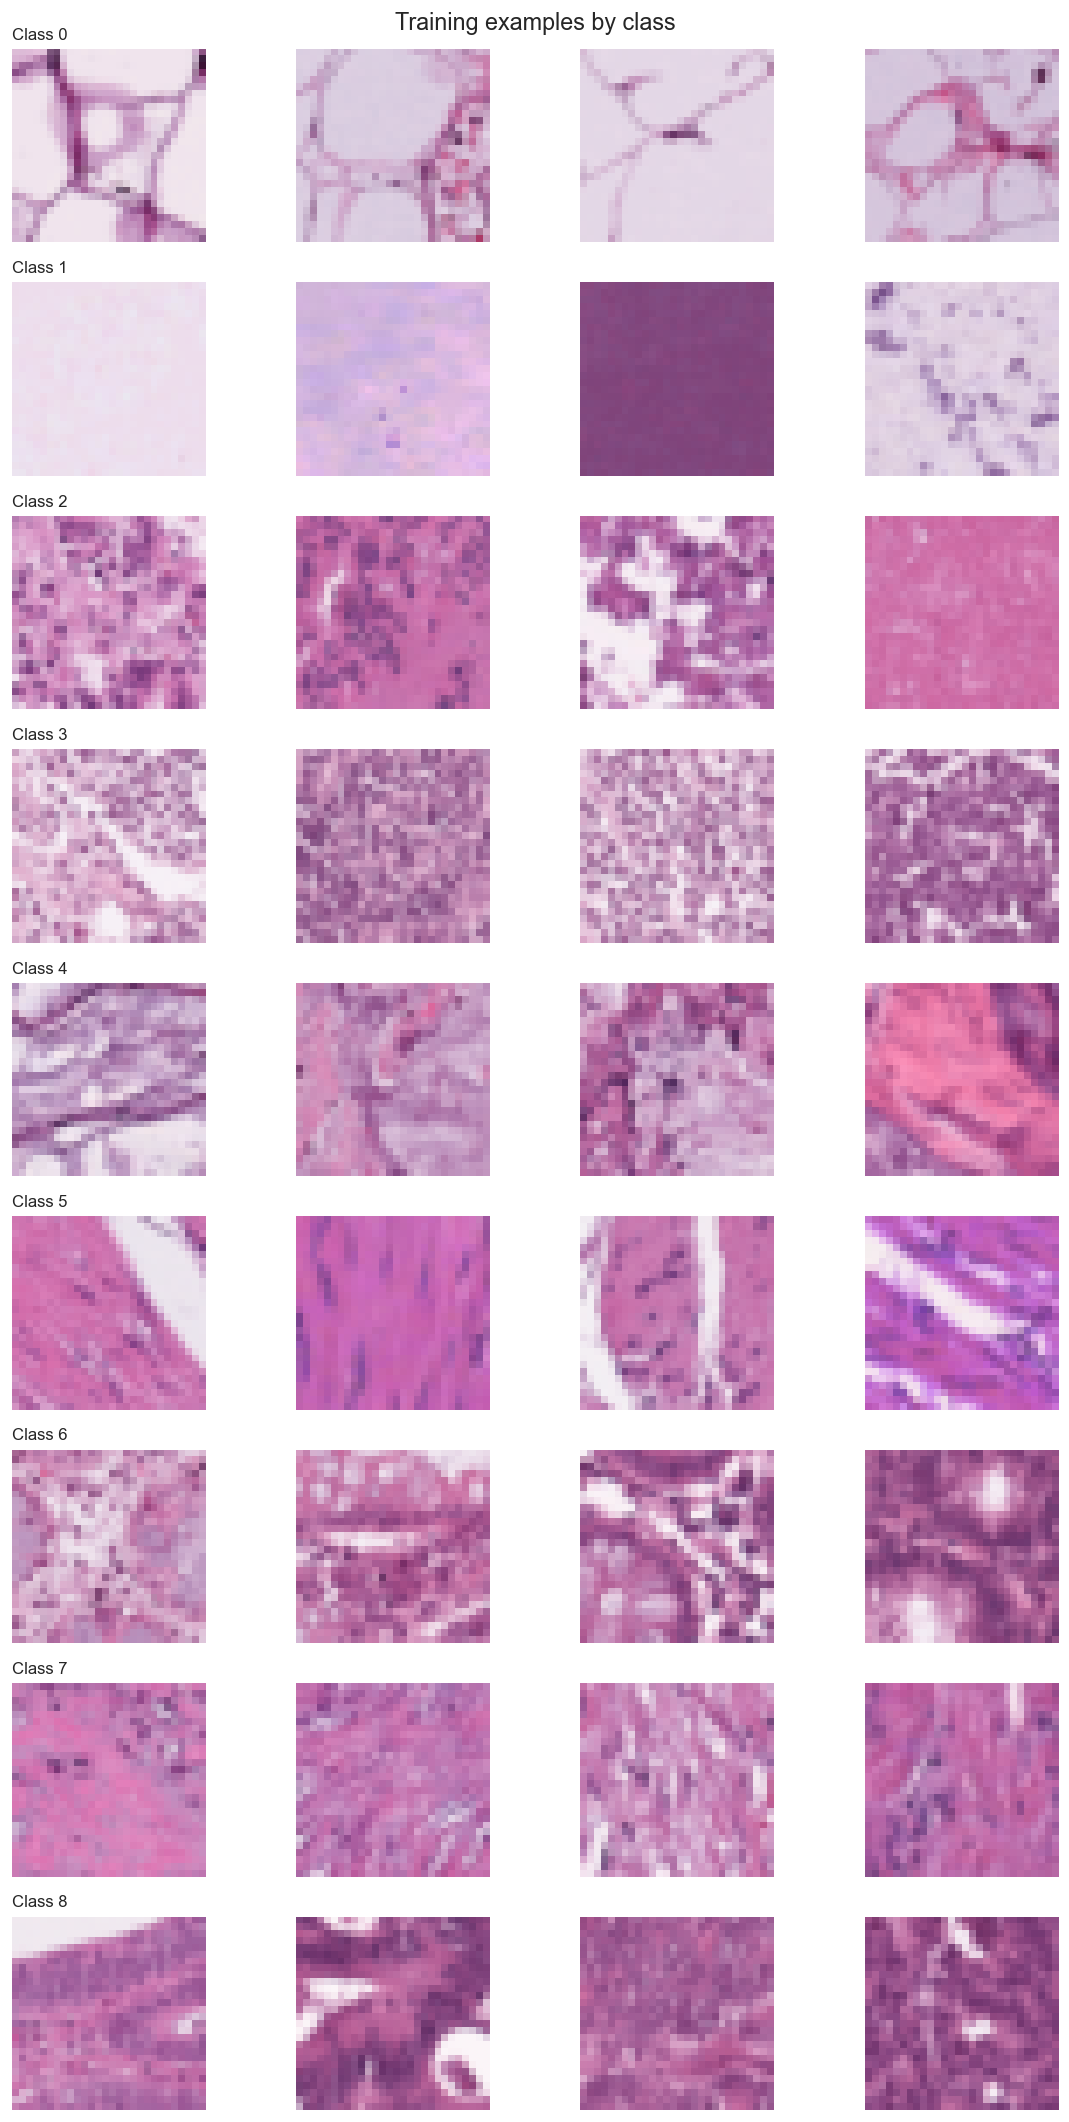

In [6]:
samples_per_class = 4
fig, axes = plt.subplots(len(class_ids), samples_per_class, figsize=(10, 18))

for row, class_id in enumerate(class_ids):
    sample_indices = np.where(y_train == class_id)[0][:samples_per_class]
    for col, sample_idx in enumerate(sample_indices):
        axes[row, col].imshow(X_train[sample_idx])
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(f'Class {class_id}', loc='left', fontsize=10)

fig.suptitle('Training examples by class', fontsize=14)
fig.tight_layout()
fig.savefig(output_dir / 'sample_images_by_class.png', bbox_inches='tight')
plt.show()

### Pixel intensity distribution
Plotting the raw pixel values helps justify scaling images to the [0, 1] range.

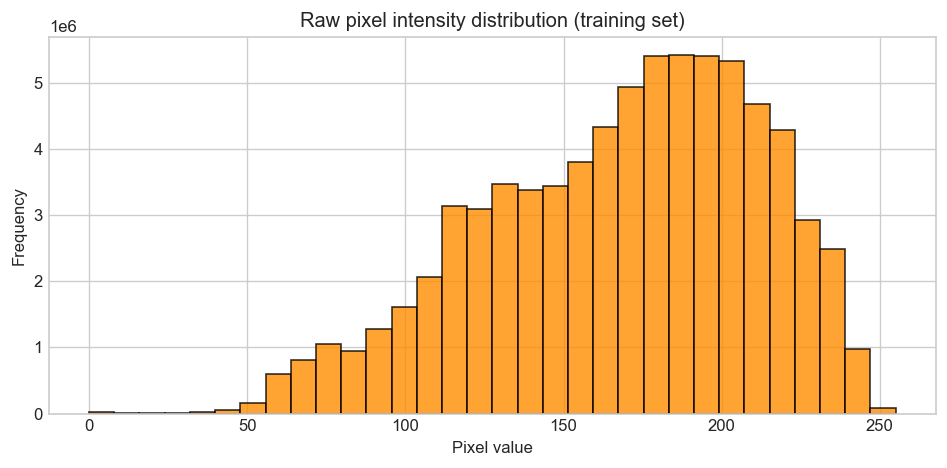

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(X_train.reshape(-1), bins=32, color='darkorange', edgecolor='black', alpha=0.8)
ax.set_title('Raw pixel intensity distribution (training set)')
ax.set_xlabel('Pixel value')
ax.set_ylabel('Frequency')
fig.tight_layout()
fig.savefig(output_dir / 'pixel_distribution.png', bbox_inches='tight')
plt.show()

### Preprocessing
The minimal preprocessing used here is image normalisation to float32 values in [0, 1], followed by a stratified train/validation split and a flattened copy for non-CNN models.

In [8]:
X_train_norm = X_train.astype(np.float32) / 255.0
X_test_norm = X_test.astype(np.float32) / 255.0

X_train_full_flat = X_train_norm.reshape(len(X_train_norm), -1)
X_test_full_flat = X_test_norm.reshape(len(X_test_norm), -1)

X_train_img, X_val_img, y_train_split, y_val = train_test_split(
    X_train_norm,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

X_train_flat = X_train_img.reshape(X_train_img.shape[0], -1)
X_val_flat = X_val_img.reshape(X_val_img.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)


search_scaler = StandardScaler()
X_train_flat_scaled = search_scaler.fit_transform(X_train_flat)
X_val_flat_scaled = search_scaler.transform(X_val_flat)
X_test_flat_scaled = search_scaler.transform(X_test_flat)

full_scaler = StandardScaler()
X_train_full_flat_scaled = full_scaler.fit_transform(X_train_full_flat)
X_test_full_flat_scaled = full_scaler.transform(X_test_full_flat)

np.save(processed_dir / 'X_train_img.npy', X_train_img)
np.save(processed_dir / 'X_val_img.npy', X_val_img)
np.save(processed_dir / 'X_test_img.npy', X_test_norm)
np.save(processed_dir / 'X_train_flat.npy', X_train_flat)
np.save(processed_dir / 'X_val_flat.npy', X_val_flat)
np.save(processed_dir / 'X_test_flat.npy', X_test_flat)
np.save(processed_dir / 'y_train.npy', y_train_split)
np.save(processed_dir / 'y_val.npy', y_val)
np.save(processed_dir / 'y_test.npy', y_test)

print('Saved processed arrays to:', processed_dir.resolve())
print(f'X_train_img shape: {X_train_img.shape}')
print(f'X_val_img shape: {X_val_img.shape}')
print(f'X_test_img shape: {X_test_norm.shape}')
print(f'X_train_flat shape: {X_train_flat.shape}')

Saved processed arrays to: /Users/tangzongquan/Desktop/COMP5318-Assignment-2/processed
X_train_img shape: (25600, 28, 28, 3)
X_val_img shape: (6400, 28, 28, 3)
X_test_img shape: (8000, 28, 28, 3)
X_train_flat shape: (25600, 2352)


### Examples of preprocessed data
The figure below compares raw and normalised images. The normalised images look visually similar, but their datatype and numeric range are now more suitable for model training.

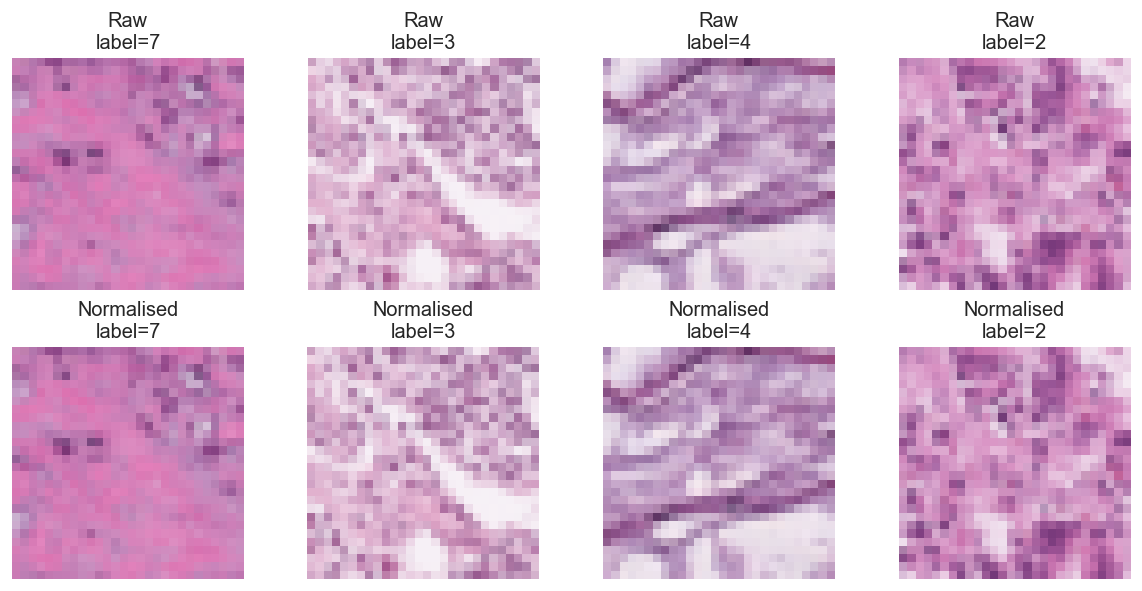

Normalised training range: [0.000, 1.000]
Flattened feature count per image: 2352


In [9]:
comparison_indices = [0, 1, 2, 3]
fig, axes = plt.subplots(2, len(comparison_indices), figsize=(10, 5))

for col, sample_idx in enumerate(comparison_indices):
    axes[0, col].imshow(X_train[sample_idx])
    axes[0, col].set_title(f'Raw\nlabel={y_train[sample_idx]}')
    axes[0, col].axis('off')

    axes[1, col].imshow(X_train_norm[sample_idx])
    axes[1, col].set_title(f'Normalised\nlabel={y_train[sample_idx]}')
    axes[1, col].axis('off')

fig.tight_layout()
fig.savefig(output_dir / 'preprocessing_comparison.png', bbox_inches='tight')
plt.show()

print(f'Normalised training range: [{X_train_norm.min():.3f}, {X_train_norm.max():.3f}]')
print(f'Flattened feature count per image: {X_train_flat.shape[1]}')

## 2. Algorithm design and setup

### Logistic Regression (Algorithm of choice from first six weeks of course)

The cell below defines the logistic regression model builder and an evaluation helper. The model takes a single key hyperparameter — the regularization strength C (default 1.0) — along with max_iter=5000 to ensure convergence on the high-dimensional input. By default it uses the lbfgs solver on CPU; when GPU acceleration is available, the solver is automatically swapped to CuML's qn with L2 penalty. The two paths are functionally equivalent — one is simply optimized for CPU and the other for GPU. Compared to the MLP and CNN used later, logistic regression is a much simpler linear model with far fewer parameters, making it a natural baseline for this assignment. A quick sanity-check fit on 100 samples is also run to confirm the class count, feature dimensionality, and total parameter count.

In [10]:
# logistic Regression model and evaluation functions

# build a logistic regression model for flattened image vectors.
def build_logistic_regression(C=1.0, solver='lbfgs', class_weight=None):
    kwargs = {
        'C': C,
        'max_iter': 5000,
    }
    
    # GPU-optimized parameters for CuML's qn solver
    if USE_CUML:
        kwargs['solver'] = 'qn'
        kwargs['penalty'] = 'l2'
        kwargs['tol'] = 1e-3
    else:
        kwargs['solver'] = solver
        kwargs['class_weight'] = class_weight
        kwargs['random_state'] = RANDOM_STATE
    
    return LogisticRegression(**kwargs)


def evaluate_predictions(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted'),
    }

lr_overview = build_logistic_regression()
lr_overview.fit(X_train_flat_scaled[:100], y_train_split[:100])  # tiny fit just to populate coef_
print(f"Logistic Regression overview:")
print(f"  Classes: {len(lr_overview.classes_)}")
print(f"  Features: {lr_overview.n_features_in_}")
print(f"  Parameters: {lr_overview.coef_.size + lr_overview.intercept_.size}")
print(f"  Solver: {lr_overview.solver}")

Logistic Regression overview:
  Classes: 9
  Features: 2352
  Parameters: 21177
  Solver: lbfgs


### Fully connected neural network
In this architecture, a series of hidden dense layers with ReLU activation are utilized to extract non-linear representations, followed by dropout regularization to improve generalization. Unlike CNNs, MLPs cannot directly process spatial dimensions; therefore, the 28×28×3 PathMNIST images are flattened into a 1D vector, resulting in an input shape of (2352,). The final output layer consists of 9 neurons, outputting the probability distribution for the 9 disease categories.

In [11]:
keras.backend.clear_session() 
tf.random.set_seed(RANDOM_STATE)


num_classes = len(np.unique(y_train_split))

def build_mlp_model(
    n_hidden_layers=2, 
    n_hidden_neurons=256,
    activation_function="relu", 
    dropout_rate=0.3,
    learning_rate=0.001,
    input_shape=None
):
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=input_shape)) 
    
    for layer in range(n_hidden_layers):
        model.add(keras.layers.Dense(n_hidden_neurons, activation=activation_function))
        model.add(keras.layers.Dropout(dropout_rate))
        
    model.add(keras.layers.Dense(num_classes, activation="softmax"))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

mlp_model_instance = build_mlp_model(input_shape=(X_train_flat_scaled.shape[1],))
mlp_model_instance.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       602,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 670,473 (2.56 MB)

 Trainable params: 670,473 (2.56 MB)

 Non-trainable params: 0 (0.00 B)

### Convolutional neural network
In this CNN, two convolutional layers are used to extract local image features, followed by max pooling to reduce the spatial dimensions, and finally a dense layer for classification. Since PathMNIST consists of 28×28 color images, the input shape is (28, 28, 3). The output layer has 9 neurons, corresponding to the 9 categories.

In [24]:
num_classes = len(np.unique(y_train_split))
input_shape = X_train_img.shape[1:]

def build_cnn_model(
    conv_filters=32,
    dense_units=128,
    dropout_rate=0.3,
    learning_rate=0.001
):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(conv_filters, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(conv_filters * 2, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ], name="cnn_model")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


cnn_model = build_cnn_model()
cnn_model.summary()

Model: "cnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,089 (1.61 MB)

 Trainable params: 422,089 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Hyperparameter tuning

### Logistic Regression (Algorithm of choice from first six weeks of course)

The cell below performs a grid search over 11 values of the regularization strength `C` (log-spaced from $10^{-5}$ to $1$) to find the optimal logistic regression hyperparameter. When CuPy is available, data arrays are transferred to GPU memory via `cp.asarray` to accelerate both training and prediction. For each `C`, the model is trained on the search split and evaluated on the held-out validation set, recording accuracy, macro F1, weighted F1, fit time, and predict time. Results are then sorted by accuracy (descending), macro F1 (descending), and fit time (ascending) to break ties, and the best `C` is extracted for later use in the final model. A horizontal bar chart visualizes validation accuracy across all 11 settings, making it easy to spot the trend in regularization strength versus performance.

Starting logistic regression tuning over 11 combinations
Using GPU acceleration: False
[1/11] Training with {'C': 1e-05}...
    done: acc=0.4533, macro_f1=0.3564, fit=17.84s, predict=0.05s
[2/11] Training with {'C': 5e-05}...
    done: acc=0.5100, macro_f1=0.4375, fit=19.35s, predict=0.03s
[3/11] Training with {'C': 0.0001}...
    done: acc=0.5195, macro_f1=0.4568, fit=26.33s, predict=0.03s
[4/11] Training with {'C': 0.0005}...
    done: acc=0.5070, macro_f1=0.4671, fit=29.30s, predict=0.03s
[5/11] Training with {'C': 0.001}...
    done: acc=0.5048, macro_f1=0.4730, fit=35.14s, predict=0.03s
[6/11] Training with {'C': 0.005}...
    done: acc=0.4891, macro_f1=0.4663, fit=49.37s, predict=0.05s
[7/11] Training with {'C': 0.01}...
    done: acc=0.4838, macro_f1=0.4639, fit=53.22s, predict=0.03s
[8/11] Training with {'C': 0.05}...
    done: acc=0.4661, macro_f1=0.4495, fit=78.63s, predict=0.03s
[9/11] Training with {'C': 0.1}...
    done: acc=0.4580, macro_f1=0.4422, fit=99.82s, predict=0.0

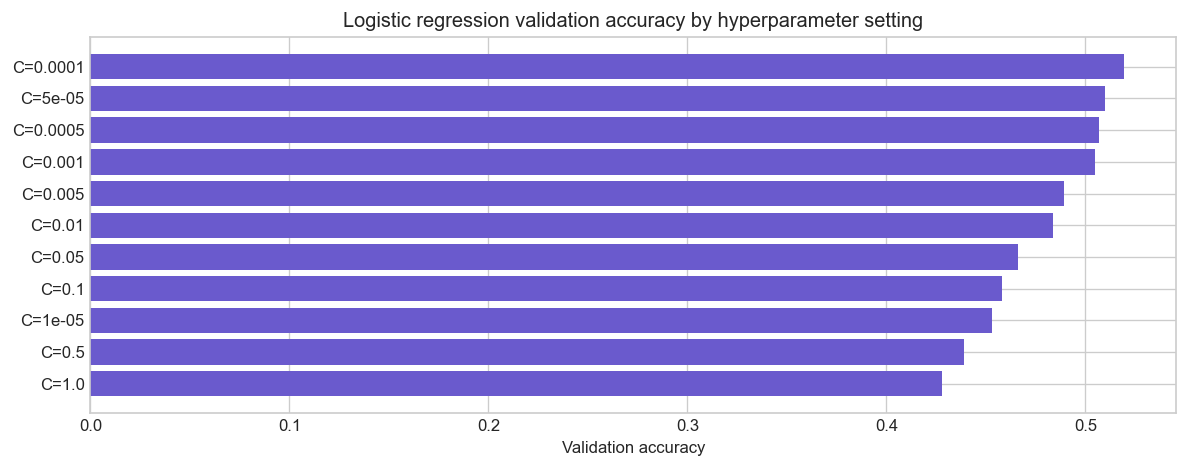

,C,accuracy,macro_f1,weighted_f1,fit_time_sec,predict_time_sec
0,0.00010,0.519531,0.456773,0.474506,26.329160,0.031799
1,0.00005,0.510000,0.437469,0.455831,19.350394,0.030992
2,0.00050,0.507031,0.467072,0.480526,29.298326,0.034922
3,0.00100,0.504844,0.472974,0.484524,35.140175,0.028638
4,0.00500,0.489063,0.466324,0.476356,49.365710,0.053103
5,0.01000,0.483750,0.463906,0.473337,53.223090,0.030854
6,0.05000,0.466094,0.449503,0.458809,78.625403,0.032509
7,0.10000,0.457969,0.442229,0.451178,99.815018,0.045091
8,0.00001,0.453281,0.356353,0.372542,17.836882,0.046352
9,0.50000,0.439219,0.426563,0.435391,186.157453,0.034809


In [13]:
# list of C for tuning
lr_param_grid = list(ParameterGrid({
    'C': [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1],
}))

print(f'Starting logistic regression tuning over {len(lr_param_grid)} combinations')
print(f'Using GPU acceleration: {USE_CUML}')
tuning_start = time.perf_counter()

# detect GPU for acceleration, fallback to CPU if not available
if HAS_CUPY:
    X_train_gpu = cp.asarray(X_train_flat_scaled)
    y_train_gpu = cp.asarray(y_train_split)
    X_val_gpu = cp.asarray(X_val_flat_scaled)
    y_val_gpu = cp.asarray(y_val)
    print("GPU acceleration enabled")
else:
    X_train_gpu = X_train_flat_scaled
    y_train_gpu = y_train_split
    X_val_gpu = X_val_flat_scaled
    y_val_gpu = y_val

lr_results = []
for i, params in enumerate(lr_param_grid, start=1):
    print(f'[{i}/{len(lr_param_grid)}] Training with {params}...', flush=True)
    model = build_logistic_regression(**params)
    fit_start = time.perf_counter()
    model.fit(X_train_gpu, y_train_gpu)
    fit_time = time.perf_counter() - fit_start

    predict_start = time.perf_counter()
    val_pred = model.predict(X_val_gpu)
    if HAS_CUPY:
        val_pred = cp.asnumpy(val_pred)
    predict_time = time.perf_counter() - predict_start

    metrics = evaluate_predictions(y_val, val_pred)
    lr_results.append({
        **params,
        **metrics,
        'fit_time_sec': fit_time,
        'predict_time_sec': predict_time,
    })

    print(
        f'    done: acc={metrics["accuracy"]:.4f}, macro_f1={metrics["macro_f1"]:.4f}, '
        f'fit={fit_time:.2f}s, predict={predict_time:.2f}s',
        flush=True,
    )

lr_results_df = pd.DataFrame(lr_results).sort_values(
    ['accuracy', 'macro_f1', 'fit_time_sec'],
    ascending=[False, False, True],
).reset_index(drop=True)
best_lr_params = {
    'C': lr_results_df.loc[0, 'C'],
}

print(f'Logistic regression tuning finished in {(time.perf_counter() - tuning_start) / 60:.2f} mins')
print('Logistic regression tuning results:')
print(lr_results_df.to_string(index=False))
print(f'Best logistic regression parameters: {best_lr_params}')

fig, ax = plt.subplots(figsize=(10, 4))
bar_labels = [f"C={row.C}" for row in lr_results_df.itertuples()]
ax.barh(bar_labels, lr_results_df['accuracy'], color='slateblue')
ax.set_xlabel('Validation accuracy')
ax.set_title('Logistic regression validation accuracy by hyperparameter setting')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

lr_results_df

### Fully connected neural network
Multi-layer perceptron

In accordance with the assignment requirements, four hyperparameters are selected for an exhaustive grid search to optimise the MLP's performance on PathMNIST.

* **Network depth (n_hidden_layers: 1, 2)** &mdash; number of hidden Dense+Dropout blocks. Deeper networks can model more complex non-linear relationships, but also have more parameters and a higher risk of overfitting on a 28&times;28 dataset.
* **Hidden width (n_hidden_neurons: 64, 128, 256)** &mdash; number of units in each hidden layer. Controls the per-layer capacity and is the dominant driver of parameter count.
* **Regularisation (dropout_rate: 0.3, 0.4, 0.5)** &mdash; probability of zeroing each hidden activation during training. Higher dropout fights overfitting at the cost of slower convergence and slightly higher bias.
* **Adam learning rate (optimizer__learning_rate: 0.001, 0.0005, 0.0001)** &mdash; step size of the Adam optimiser. Controls the speed/stability trade-off; smaller values converge more reliably but require more epochs.

The full grid contains 2 &times; 3 &times; 3 &times; 3 = **54 unique combinations**, evaluated using a held-out validation set (the same approach used for CNN tuning). The flattened features are standardised with search_scaler (fit only on the training subset) so the validation fold remains a clean hold-out.

In [14]:
# MLP tuning with KerasTuner — reuses build_mlp_model
def build_mlp_tunable(hp):
    return build_mlp_model(
        n_hidden_layers=hp.Choice('n_hidden_layers', [1, 2]),
        n_hidden_neurons=hp.Choice('n_hidden_neurons', [64, 128, 256]),
        dropout_rate=hp.Choice('dropout_rate', [0.3, 0.4, 0.5]),
        learning_rate=hp.Choice('learning_rate', [0.001, 0.0005, 0.0001]),
        input_shape=(X_train_flat_scaled.shape[1],),
    )

# grid search over 2×3×3×3 = 54 combinations of MLP hyperparameters
mlp_tuner = kt.GridSearch(
    build_mlp_tunable,
    objective='val_accuracy',
    max_trials=54,
    directory='./kt_models/mlp_tuning',
    project_name='mlp_grid'
)

print("Starting KerasTuner GridSearch over 54 combinations (2×3×3×3)...")
start_time = time.time()

mlp_tuner.search(
    X_train_flat_scaled, y_train_split,
    validation_data=(X_val_flat_scaled, y_val),
    epochs=10, batch_size=64, verbose=1
)

print(f"\nGrid search complete, overall time used: {(time.time() - start_time) / 60:.2f} mins")

Reloading Tuner from ./kt_models/mlp_tuning/mlp_grid/tuner0.json
Starting KerasTuner GridSearch over 54 combinations (2×3×3×3)...

Grid search complete, overall time used: 0.00 mins


In [15]:
# result dataframe for MLP tuning
mlp_trials = mlp_tuner.oracle.get_best_trials(num_trials=54)

mlp_tuning_results = []
for trial in mlp_trials:
    mlp_tuning_results.append({
        'n_hidden_layers': trial.hyperparameters.values['n_hidden_layers'],
        'n_hidden_neurons': trial.hyperparameters.values['n_hidden_neurons'],
        'dropout_rate': trial.hyperparameters.values['dropout_rate'],
        'learning_rate': trial.hyperparameters.values['learning_rate'],
        'val_accuracy': trial.score,
    })

mlp_tuning_results_df = pd.DataFrame(mlp_tuning_results).sort_values(
    'val_accuracy', ascending=False
).reset_index(drop=True)

display_cols = ['n_hidden_layers', 'n_hidden_neurons', 
                'dropout_rate', 'learning_rate', 'val_accuracy']

print("\n--- Top 10 combinations ---")
display(mlp_tuning_results_df[display_cols].head(10))


--- Top 10 combinations ---


,n_hidden_layers,n_hidden_neurons,dropout_rate,learning_rate,val_accuracy
0,2,256,0.3,0.0005,0.637812
1,2,256,0.3,0.0010,0.630938
2,2,256,0.3,0.0001,0.627813
3,2,256,0.4,0.0005,0.625000
4,2,128,0.3,0.0005,0.624531
5,1,256,0.5,0.0005,0.622969
6,2,128,0.3,0.0010,0.622656
7,1,256,0.4,0.0005,0.622500
8,1,256,0.3,0.0005,0.618281
9,1,256,0.3,0.0001,0.616406


In [16]:
best_mlp_hps = mlp_tuner.get_best_hyperparameters()[0]
best_mlp_score = mlp_tuner.oracle.get_best_trials(1)[0].score

print(f"Best validation accuracy: {best_mlp_score:.4f}")
print("The optimal combination of hyperparameters found:")
for param, value in best_mlp_hps.values.items():
    print(f"  {param}: {value}")

Best validation accuracy: 0.6378
The optimal combination of hyperparameters found:
  n_hidden_layers: 2
  n_hidden_neurons: 256
  dropout_rate: 0.3
  learning_rate: 0.0005


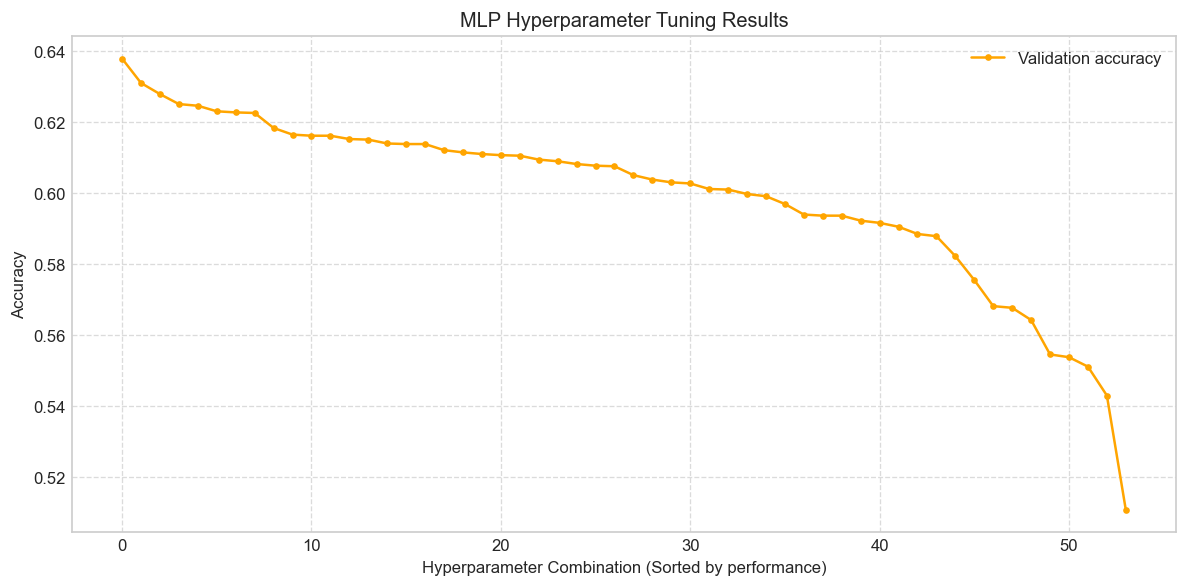

In [17]:
# visualize MLP tuning results, combinations vs validation accuracy
fig, ax = plt.subplots(figsize=(10, 5)) 

ax.plot(
    range(len(mlp_tuning_results_df)),
    mlp_tuning_results_df['val_accuracy'],
    marker='.', 
    linestyle='-',
    color='orange',
    label='Validation accuracy'
)

ax.set_title('MLP Hyperparameter Tuning Results')
ax.set_xlabel('Hyperparameter Combination (Sorted by performance)')
ax.set_ylabel('Accuracy')
ax.legend()

ax.grid(True, linestyle='--', alpha=0.7)

fig.tight_layout()
fig.savefig(output_dir / 'mlp_hyperparameter_tuning.png', bbox_inches='tight', dpi=300)
plt.show()

### Convolutional neural network
In accordance with the assignment requirements, four hyperparameters were selected for an exhaustive grid search to optimise the CNN model on the PathMNIST image classification task.

Convolution filters (`conv_filters`: 32, 64) — the number of filters in the first convolutional layer. The second convolutional layer uses twice this number of filters. Increasing the number of filters allows the CNN to learn more local image patterns and texture features, but also increases the number of parameters and runtime.

Dense layer size (`dense_units`: 64, 128, 256) — the number of neurons in the fully connected layer after the convolution and pooling layers. This controls the capacity of the final classification part of the model. Larger dense layers can learn more complex feature combinations, but may also increase the risk of overfitting.

Regularisation (`dropout_rate`: 0.3, 0.4, 0.5) — the proportion of dense-layer activations randomly set to zero during training. Dropout is used to reduce overfitting. A higher dropout rate provides stronger regularisation, but may also make learning slower or cause underfitting if too much information is removed.

Adam learning rate (`learning_rate`: 0.001, 0.0005, 0.0001) — the initial step size used by the Adam optimiser. A larger learning rate can train faster but may be less stable, while a smaller learning rate can be more stable but may require more epochs to converge.

The full grid contains 2 × 3 × 3 × 3 = 54 unique hyperparameter combinations. Each combination is trained on the training subset and evaluated using the held-out validation set. The validation accuracy is used as the selection criterion because the test set should only be used for the final model comparison.

In [25]:
# CNN tuning with KerasTuner — reuses build_cnn_model
def build_cnn_tunable(hp):
    return build_cnn_model(
        conv_filters=hp.Choice('conv_filters', [32, 64]),
        dense_units=hp.Choice('dense_units', [64, 128, 256]),
        dropout_rate=hp.Choice('dropout_rate', [0.3, 0.4, 0.5]),
        learning_rate=hp.Choice('learning_rate', [0.001, 0.0005, 0.0001]),
    )

# grid search over 2×3×3×3 = 54 combinations of CNN hyperparameters
cnn_tuner = kt.GridSearch(
    build_cnn_tunable,
    objective='val_accuracy',
    max_trials=54,
    directory='./kt_models/cnn_tuning',
    project_name='cnn_grid'
)

print("Starting KerasTuner GridSearch over 54 combinations (2×3×3×3)...")
start_time = time.time()

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

cnn_tuner.search(
    X_train_img, y_train_split,
    validation_data=(X_val_img, y_val),
    epochs=10, batch_size=128, verbose=1,
    callbacks=[reduce_lr]
)

print(f"\nGrid search complete, overall time used: {(time.time() - start_time) / 60:.2f} mins")

Reloading Tuner from ./kt_models/cnn_tuning/cnn_grid/tuner0.json
Starting KerasTuner GridSearch over 54 combinations (2×3×3×3)...

Grid search complete, overall time used: 0.00 mins


Then select the optimal parameters and save the results.

In [26]:
# result dataframe for CNN tuning
cnn_trials = cnn_tuner.oracle.get_best_trials(num_trials=54)

cnn_tuning_results = []
for trial in cnn_trials:
    cnn_tuning_results.append({
        'conv_filters': trial.hyperparameters.values['conv_filters'],
        'dense_units': trial.hyperparameters.values['dense_units'],
        'dropout_rate': trial.hyperparameters.values['dropout_rate'],
        'learning_rate': trial.hyperparameters.values['learning_rate'],
        'val_accuracy': trial.score,
    })

cnn_tuning_results_df = pd.DataFrame(cnn_tuning_results).sort_values(
    'val_accuracy', ascending=False
).reset_index(drop=True)

display_cols = ['conv_filters', 'dense_units',
                'dropout_rate', 'learning_rate', 'val_accuracy']

print("\n--- Top 10 combinations ---")
display(cnn_tuning_results_df[display_cols].head(10))


--- Top 10 combinations ---


,conv_filters,dense_units,dropout_rate,learning_rate,val_accuracy
0,64,128,0.3,0.0010,0.800469
1,32,256,0.4,0.0010,0.798281
2,64,256,0.3,0.0010,0.796719
3,64,256,0.4,0.0010,0.796406
4,64,256,0.4,0.0005,0.795781
5,64,128,0.4,0.0005,0.794531
6,64,256,0.5,0.0010,0.793906
7,64,256,0.3,0.0005,0.790000
8,32,256,0.4,0.0005,0.788750
9,64,128,0.3,0.0005,0.788594


In [27]:
# Automatically select the set of parameters with the highest validation accuracy from the 54 sets of CNN hyperparameter search results
best_cnn_hps = cnn_tuner.get_best_hyperparameters()[0]
best_cnn_score = cnn_tuner.oracle.get_best_trials(1)[0].score

print(f"Best validation accuracy: {best_cnn_score:.4f}")
print("The optimal combination of hyperparameters found:")
for param, value in best_cnn_hps.values.items():
    print(f"  {param}: {value}")

Best validation accuracy: 0.8005
The optimal combination of hyperparameters found:
  conv_filters: 64
  dense_units: 128
  dropout_rate: 0.3
  learning_rate: 0.001


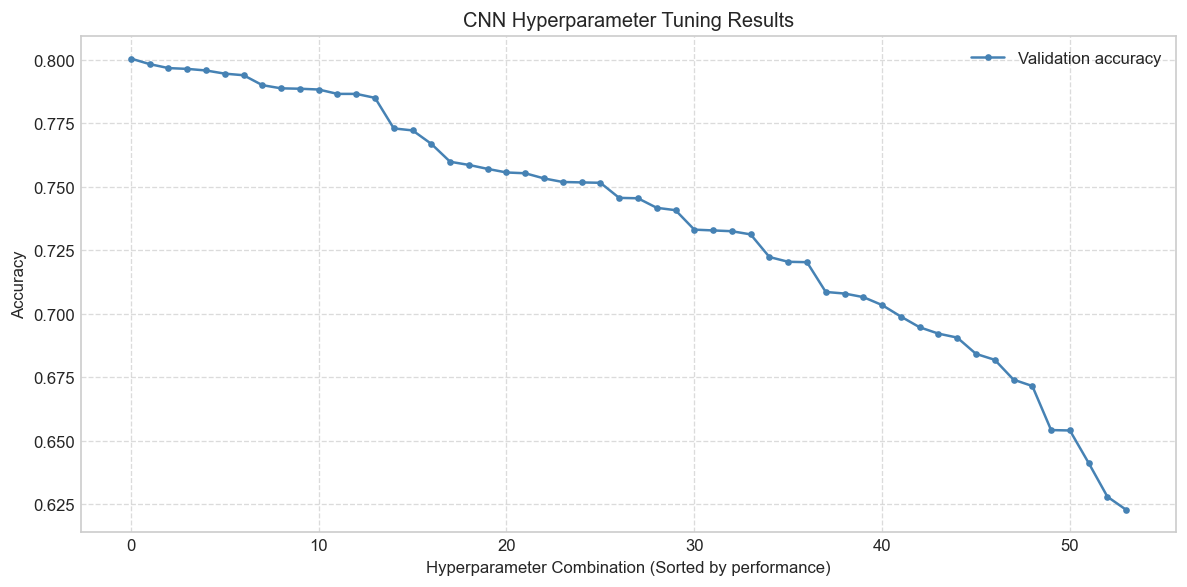

In [21]:
# visualize CNN tuning results, sorted by performance
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    range(len(cnn_tuning_results_df)),
    cnn_tuning_results_df['val_accuracy'],
    marker='.',
    linestyle='-',
    color='steelblue',
    label='Validation accuracy'
)

ax.set_title('CNN Hyperparameter Tuning Results')
ax.set_xlabel('Hyperparameter Combination (Sorted by performance)')
ax.set_ylabel('Accuracy')
ax.legend()

ax.grid(True, linestyle='--', alpha=0.7)

fig.tight_layout()
fig.savefig(output_dir / 'cnn_hyperparameter_tuning.png', bbox_inches='tight', dpi=300)
plt.show()

## 4. Final models
In this section, please ensure to include cells to train each model with its best hyperparmater combination independently of the hyperparameter tuning cells, i.e. don't rely on the hyperparameter tuning cells having been run.

### Logistic Regression (Algorithm of choice from first six weeks of course)

The cell below trains the final logistic regression model using the best C found during tuning. It fits on the full training set, evaluates on the test set, and reports accuracy, macro F1, weighted F1, parameter count, and runtime — all with GPU acceleration via CuPy when available.

In [22]:
# use best hyperparameters from tuning
try:
    lr_final_params = best_lr_params
    print(f"Using best params from tuning: {lr_final_params}")
except NameError:
    lr_final_params = {'C': 0.0001}
    print(f"Tuning results not found, using fallback: {lr_final_params}")

final_lr_model = build_logistic_regression(**lr_final_params)

# use GPU acceleration for final training, fallback to CPU if not available
if HAS_CUPY:
    X_train_full_gpu = cp.asarray(X_train_full_flat_scaled)
    y_train_gpu = cp.asarray(y_train)
    X_test_full_gpu = cp.asarray(X_test_full_flat_scaled)
else:
    X_train_full_gpu = X_train_full_flat_scaled
    y_train_gpu = y_train
    X_test_full_gpu = X_test_full_flat_scaled

fit_start = time.perf_counter()
final_lr_model.fit(X_train_full_gpu, y_train_gpu)
lr_fit_time = time.perf_counter() - fit_start

predict_start = time.perf_counter()
lr_test_pred = final_lr_model.predict(X_test_full_gpu)
if HAS_CUPY:
    lr_test_pred = cp.asnumpy(lr_test_pred)
lr_predict_time = time.perf_counter() - predict_start

lr_test_metrics = evaluate_predictions(y_test, lr_test_pred)
lr_final_summary = {
    'model': 'Logistic regression',
    'best_hyperparameters': f"C={lr_final_params['C']}",
    'params': int(final_lr_model.coef_.size + final_lr_model.intercept_.size),
    **lr_test_metrics,
    'fit_time_sec': lr_fit_time,
    'predict_time_sec': lr_predict_time,
}

print('Final logistic regression test results:')
print(lr_final_summary)

Using best params from tuning: {'C': np.float64(0.0001)}
Final logistic regression test results:
{'model': 'Logistic regression', 'best_hyperparameters': 'C=0.0001', 'params': 21177, 'accuracy': 0.527375, 'macro_f1': 0.46703288208114774, 'weighted_f1': 0.4834030975120031, 'fit_time_sec': 32.138427792117, 'predict_time_sec': 0.052835458889603615}


Since the GPU-accelerated training is involved, the accuracy cannot be a fixed value, about 51%-57% is expected.


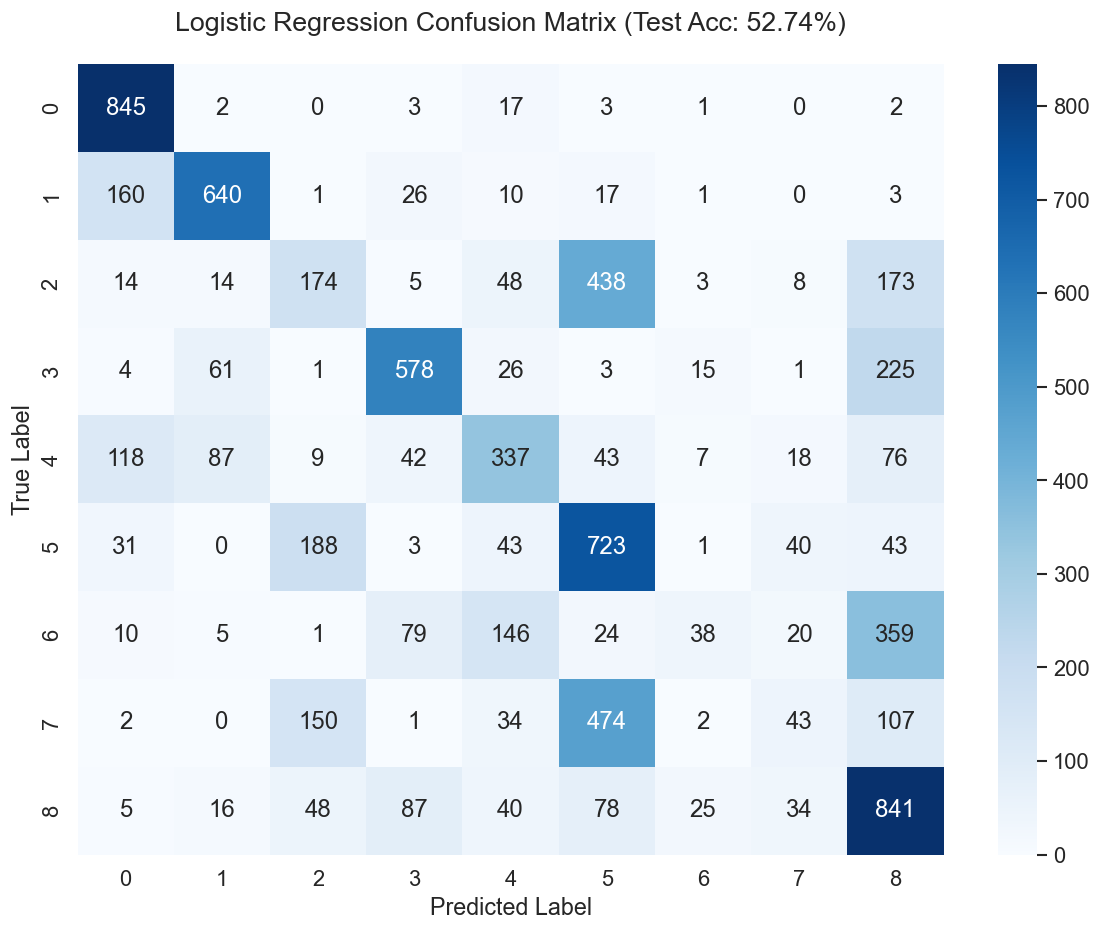

In [23]:
# Confusion matrix
cm = confusion_matrix(y_test, lr_test_pred)

plt.figure(figsize=(10, 8))
sns.set_theme(font_scale=1.2)

# Drawing a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))

plt.title(f'Logistic Regression Confusion Matrix (Test Acc: {lr_test_metrics["accuracy"]:.2%})', pad=20, fontsize=16)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()

print("Since the GPU-accelerated training is involved, the accuracy cannot be a fixed value, about 51%-57% is expected.")

plt.savefig(output_dir / 'log_reg_confusion_matrix.png', dpi=300)
plt.show()

### Fully connected neural network

In [24]:
keras.backend.clear_session()
keras.utils.set_random_seed(RANDOM_STATE)

try:
    best_mlp_params = dict(best_mlp_hps.values)
    print(f"Using best params from KerasTuner: {best_mlp_params}")
except NameError:
    best_mlp_params = {
        'n_hidden_layers': 1,
        'n_hidden_neurons': 256,
        'dropout_rate': 0.3,
        'learning_rate': 0.001,
    }
    print(f"Tuner results unavailable, using fallback: {best_mlp_params}")

final_mlp_model = build_mlp_model(
    n_hidden_layers=best_mlp_params['n_hidden_layers'],
    n_hidden_neurons=best_mlp_params['n_hidden_neurons'],
    dropout_rate=best_mlp_params['dropout_rate'],
    learning_rate=best_mlp_params['learning_rate'],
    input_shape=(X_train_full_flat_scaled.shape[1],),
)

# use larger epochs for final training to achieve better convergence
mlp_start_time = time.time()
final_mlp_history = final_mlp_model.fit(
    X_train_full_flat_scaled,
    y_train,
    epochs=30,
    batch_size=64,
    verbose=1,
)
final_mlp_runtime = time.time() - mlp_start_time
print(f"MLP final training runtime: {final_mlp_runtime:.2f} seconds")


mlp_test_probs = final_mlp_model.predict(X_test_full_flat_scaled, verbose=0)
y_pred_mlp = np.argmax(mlp_test_probs, axis=1)

test_accuracy = accuracy_score(y_test, y_pred_mlp)
print(f"\nAccuracy of MLP model on test set: {test_accuracy:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_mlp, digits=4, zero_division=0))

Using best params from KerasTuner: {'n_hidden_layers': 2, 'n_hidden_neurons': 256, 'dropout_rate': 0.3, 'learning_rate': 0.0005}
Epoch 1/30


I0000 00:00:1778218684.913118   53462 service.cc:146] XLA service 0x7aa16c016aa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778218684.913214   53462 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5080, Compute Capability 12.0


  1/500 ━━━━━━━━━━━━━━━━━━━━ 13:18 2s/step - accuracy: 0.1875 - loss: 2.3597

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1778218685.739715   53462 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3904 - loss: 1.6778
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5362 - loss: 1.2222
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5662 - loss: 1.1269
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5917 - loss: 1.0596
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6117 - loss: 1.0110
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6318 - loss: 0.9561
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6412 - loss: 0.9310
Epoch 8/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6520 - loss: 0.9062
Epoch 9/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6661 - loss: 0.8700
Epoch 10/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6729 - loss: 0.8484
Epoch 11/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6804 - loss: 0.8285
Epoch 12/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)



Accuracy of MLP model on test set: 0.6693

--- Classification Report ---
              precision    recall  f1-score   support

           0     0.8129    0.9656    0.8827       873
           1     0.9454    0.9079    0.9263       858
           2     0.5452    0.4265    0.4786       877
           3     0.9020    0.8260    0.8624       914
           4     0.6443    0.5604    0.5994       737
           5     0.6447    0.6399    0.6423      1072
           6     0.4415    0.4868    0.4630       682
           7     0.4864    0.5264    0.5056       813
           8     0.5817    0.6337    0.6066      1174

    accuracy                         0.6693      8000
   macro avg     0.6671    0.6637    0.6630      8000
weighted avg     0.6711    0.6693    0.6678      8000



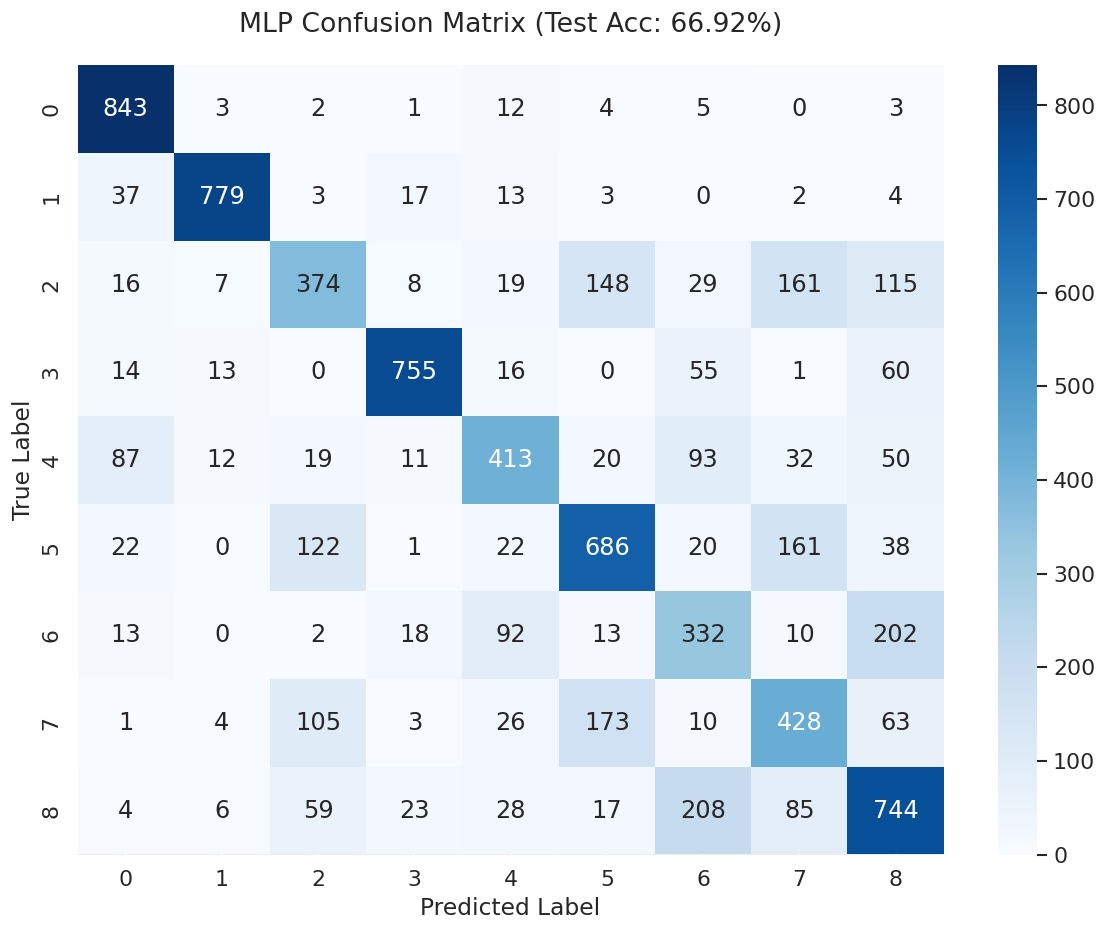

In [25]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_mlp)


plt.figure(figsize=(10, 8))
sns.set_theme(font_scale=1.2)

# Drawing a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))

plt.title(f'MLP Confusion Matrix (Test Acc: {test_accuracy:.2%})', pad=20, fontsize=16)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()

plt.savefig(output_dir / 'mlp_confusion_matrix.png', dpi=300)
plt.show()

### Convolutional neural network

In [ ]:
keras.backend.clear_session()
keras.utils.set_random_seed(RANDOM_STATE)

try:
    best_cnn_params = dict(best_cnn_hps.values)
    print(f"Using best params from KerasTuner: {best_cnn_params}")
except NameError:
    best_cnn_params = {
        'conv_filters': 64,
        'dense_units': 256,
        'dropout_rate': 0.3,
        'learning_rate': 0.001,
    }
    print(f"Tuner results unavailable, using fallback: {best_cnn_params}")

final_cnn_model = build_cnn_model(**best_cnn_params)

start_time = time.time()

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

final_cnn_history = final_cnn_model.fit(
    X_train_img,
    y_train_split,
    validation_data=(X_val_img, y_val),
    epochs=30,
    batch_size=128,
    verbose=1,
    callbacks=[reduce_lr]
)

final_cnn_runtime = time.time() - start_time

Using best params from KerasTuner: {'conv_filters': 64, 'dense_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001}
Epoch 1/30


In [27]:
# Test Set Evaluation
cnn_test_loss, cnn_test_accuracy = final_cnn_model.evaluate(
    X_test_norm,
    y_test,
    verbose=0
)

cnn_test_probabilities = final_cnn_model.predict(X_test_norm)
cnn_test_predictions = np.argmax(cnn_test_probabilities, axis=1)

print(f'CNN test accuracy: {cnn_test_accuracy:.4f}')
print(f'CNN test loss: {cnn_test_loss:.4f}')
print(f'CNN final training runtime: {final_cnn_runtime:.2f} seconds')

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


100/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step
CNN test accuracy: 0.8375
CNN test loss: 0.4472
CNN final training runtime: 17.39 seconds


In [28]:
# Print Categorized Report
print(classification_report(y_test, cnn_test_predictions, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      0.98      0.96       873
           1       0.98      0.96      0.97       858
           2       0.77      0.69      0.73       877
           3       0.94      0.98      0.96       914
           4       0.85      0.80      0.82       737
           5       0.80      0.82      0.81      1072
           6       0.72      0.72      0.72       682
           7       0.68      0.65      0.66       813
           8       0.82      0.88      0.85      1174

    accuracy                           0.84      8000
   macro avg       0.83      0.83      0.83      8000
weighted avg       0.84      0.84      0.84      8000



In [28]:
# Confusion matrix
cm = confusion_matrix(y_test, cnn_test_predictions)


plt.figure(figsize=(10, 8))
sns.set_theme(font_scale=1.2)

# Drawing a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))

plt.title(f'CNN Confusion Matrix (Test Acc: {cnn_test_accuracy:.2%})', pad=20, fontsize=16)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()

print("Due to random initialization and stochastic mini-batch training, the final test accuracy may vary slightly between runs.")
plt.savefig(output_dir / 'cnn_confusion_matrix.png', dpi=300)
plt.show()

NameError: name 'cnn_test_predictions' is not defined

## 5. AI Acknowledgement

### Generative AI Tools Used

The primary generative AI tool used throughout this assignment was **ChatGPT** (OpenAI, GPT-5 model).

### How Generative AI Tools Were Used

We mainly used AI tools to assist with this assignment by seeking the help for the usage of functions such as Keras and TensorFlow, explaining the concepts behind the models for better understanding, and polish the markdown cells.